In [1]:
import json
import requests
import pyotp
from urllib import parse
import sys
from fyers_apiv3 import fyersModel
import os

FY_ID = "XT07804"  # Your fyers ID
APP_ID_TYPE = "2"  # Keep default as 2, It denotes web login
TOTP_KEY = "ADD5SCDJLI46IPNAUVZJZ2XJLWBJCSXX"  # TOTP secret is generated when we enable 2Factor TOTP from myaccount portal
PIN = "1997"  # User pin for fyers account
APP_ID = "63TGM29OEI"  # App ID from myapi dashboard is in the form appId-appType. Example - EGNI8CE27Q-100, In this code EGNI8CE27Q will be APP_ID and 100 will be the APP_TYPE
REDIRECT_URI = "https://localhost:8000"  # Redirect url from the app.
APP_TYPE = "100"
APP_ID_HASH = "3827b729395e684c1510fdf936c786cc3f57f982fff83f1a3379adbb6bcd9242"  # SHA-256 hash of appId-appType:appSecret

# API endpoints
BASE_URL = "https://api-t2.fyers.in/vagator/v2"
BASE_URL_2 = "https://api.fyers.in/api/v2"
URL_SEND_LOGIN_OTP = BASE_URL + "/send_login_otp"
URL_VERIFY_TOTP = BASE_URL + "/verify_otp"
URL_VERIFY_PIN = BASE_URL + "/verify_pin"
URL_TOKEN = BASE_URL_2 + "/token"
URL_VALIDATE_AUTH_CODE = BASE_URL_2 + "/validate-authcode"

SUCCESS = 1
ERROR = -1

def send_login_otp(fy_id, app_id):
    try:
        payload = {
            "fy_id": fy_id,
            "app_id": app_id
        }

        result_string = requests.post(url=URL_SEND_LOGIN_OTP, json=payload)
        if result_string.status_code != 200:
            return [ERROR, result_string.text]

        result = json.loads(result_string.text)
        request_key = result["request_key"]

        return [SUCCESS, request_key]
    
    except Exception as e:
        return [ERROR, e]
    

def generate_totp(secret):
    try:
        generated_totp = pyotp.TOTP(secret).now()
        return [SUCCESS, generated_totp]
    
    except Exception as e:
        return [ERROR, e]


def verify_totp(request_key, totp):
    try:
        payload = {
            "request_key": request_key,
            "otp": totp
        }

        result_string = requests.post(url=URL_VERIFY_TOTP, json=payload)
        if result_string.status_code != 200:
            return [ERROR, result_string.text]

        result = json.loads(result_string.text)
        request_key = result["request_key"]

        return [SUCCESS, request_key]
    
    except Exception as e:
        return [ERROR, e]


def verify_PIN(request_key, pin):
    try:
        payload = {
            "request_key": request_key,
            "identity_type": "pin",
            "identifier": pin
        }

        result_string = requests.post(url=URL_VERIFY_PIN, json=payload)
        if result_string.status_code != 200:
            return [ERROR, result_string.text]
    
        result = json.loads(result_string.text)
        access_token = result["data"]["access_token"]
        print(result)
        return [SUCCESS, access_token]
    
    except Exception as e:
        return [ERROR, e]


def token(fy_id, app_id, redirect_uri, app_type, access_token):
    try:
        payload = {
            "fyers_id": fy_id,
            "app_id": app_id,
            "redirect_uri": redirect_uri,
            "appType": app_type,
            "code_challenge": "",
            "state": "sample_state",
            "scope": "",
            "nonce": "",
            "response_type": "code",
            "create_cookie": True
        }
        headers={'Authorization': f'Bearer {access_token}'}

        result_string = requests.post(
            url=URL_TOKEN, json=payload, headers=headers
        )
        print(result_string.status_code)
        if result_string.status_code != 308:
            return [ERROR, result_string.text]

        result = json.loads(result_string.text)
        url = result["Url"]
        print(result)
        auth_code = parse.parse_qs(parse.urlparse(url).query)['auth_code'][0]

        return [SUCCESS, auth_code]
    
    except Exception as e:
        return [ERROR, e]


def validate_authcode(app_id_hash, auth_code):
    try:
        payload = {
            "grant_type": "authorization_code",
            "appIdHash": app_id_hash,
            "code": auth_code,
        }

        result_string = requests.post(url=URL_VALIDATE_AUTH_CODE, json=payload)
        if result_string.status_code != 200:
            return [ERROR, result_string.text]

        result = json.loads(result_string.text)
        access_token = result["access_token"]

        return [SUCCESS, access_token]
    
    except Exception as e:
        return [ERROR, e]

# Step 1 - Retrieve request_key from send_login_otp API
send_otp_result = send_login_otp(fy_id=FY_ID, app_id=APP_ID_TYPE)
if send_otp_result[0] != SUCCESS:
    print(f"send_login_otp failure - {send_otp_result[1]}")
    sys.exit()
else:
    print("send_login_otp success")

    # Step 2 - Generate totp
generate_totp_result = generate_totp(secret=TOTP_KEY)
if generate_totp_result[0] != SUCCESS:
    print(f"generate_totp failure - {generate_totp_result[1]}")
    sys.exit()
else:
    print("generate_totp success")

# Step 3 - Verify totp and get request key from verify_otp API
request_key = send_otp_result[1]
totp = generate_totp_result[1]
verify_totp_result = verify_totp(request_key=request_key, totp=totp)
if verify_totp_result[0] != SUCCESS:
    print(f"verify_totp_result failure - {verify_totp_result[1]}")
    sys.exit()
else:
    print("verify_totp_result success")


# Step 4 - Verify pin and send back access token
request_key_2 = verify_totp_result[1]
verify_pin_result = verify_PIN(request_key=request_key_2, pin=PIN)
if verify_pin_result[0] != SUCCESS:
    print(f"verify_pin_result failure - {verify_pin_result[1]}")
    sys.exit()
else:
    print("verify_pin_result success,")

    # Step 5 - Get auth code for API V2 App from trade access token
token_result = token(
    fy_id=FY_ID, app_id=APP_ID, redirect_uri=REDIRECT_URI, app_type=APP_TYPE,
    access_token=verify_pin_result[1]
)
print(token_result,verify_pin_result[1])
if token_result[0] != SUCCESS:
    print(f"token_result failure - {token_result[1]}")
    sys.exit()
else:
    print("token_result success")

# Step 6 - Get API V2 access token from validating auth code
auth_code = token_result[1]
validate_authcode_result = validate_authcode(
    app_id_hash=APP_ID_HASH, auth_code=auth_code
)
# print(auth_code)
if token_result[0] != SUCCESS:
    print(f"validate_authcode failure - {validate_authcode_result[1]}")
    sys.exit()
else:
    print("validate_authcode success")

access_token = APP_ID + "-" + APP_TYPE + ":" + validate_authcode_result[1]

# print(f"access_token - {access_token}")
fyers_log_path = os.path.join(os.getcwd(), "Fyers_logs")

client_id = validate_authcode_result[0]
fyers = fyersModel.FyersModel(client_id=client_id, is_async=False, token=validate_authcode_result[1],log_path=os.getcwd())
fyers.token=validate_authcode_result[1]

send_login_otp success
generate_totp success
verify_totp_result success
{'s': 'ok', 'code': 1004, 'message': 'Pin is Verified', 'data': {'refresh_token': 'eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJodHRwczovL2xvZ2luLmZ5ZXJzLmluIiwiaWF0IjoxNzI0NjkzMzYxLCJleHAiOjE3MzI0NjkzNjEsIm5iZiI6MTcyNDY5MzM2MSwiYXVkIjpbIng6MCIsIng6MSIsIng6MiIsImQ6MSJdLCJzdWIiOiJyZWZyZXNoX3Rva2VuIiwiYXRfaGFzaCI6ImdBQUFBQUJtekx0eGMzbDBLSkNVZWY4ek5reFJmU1RXbjhOLVZOQXp1c0RiNmsyMUFtSjU3VTlvNzJ1Z2ZTTndKVTRJSnZmblhhVXJZZHZMNkNPbTFFTTJlWkVrZG0yNkFQcUk4UkNOXzc4TlN2ZG9Ic0lVRFM0PSIsImRpc3BsYXlfbmFtZSI6IlRBSEVSIFNIQUJCSVIgSFVTQUlOIFNBUkFGIiwiZnlfaWQiOiJYVDA3ODA0IiwiYXBwVHlwZSI6IiIsInBvYV9mbGFnIjoiTiIsImlzTXRmRW5hYmxlZCI6Ik4iLCJpc0RkcGlFbmFibGVkIjoiTiIsImN1Z19tdGYiOiJZIn0.Q6vzcOl0Hmv91EgEuT2cETa8sgbYfJ-KTYw12T-Z_BQ', 'access_token': 'eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJodHRwczovL2xvZ2luLmZ5ZXJzLmluIiwiaWF0IjoxNzI0NjkzMzYxLCJleHAiOjE3MjQ3MTg2MjEsIm5iZiI6MTcyNDY5MzM2MSwiYXVkIjpbIng6MCIsIng6MSIsIng6MiIsImQ6MSJdLCJz

In [25]:
df.to_excel('optins_data.xlsx')

In [6]:
import time
import pandas as pd
import py_vollib.black_scholes.greeks.analytical as derivatives
from datetime import datetime, timedelta

# Function to get the Bank Nifty price for a specific timestamp
def get_banknifty_price_at(timestamp_start, timestamp_end):
    data_bn = {
        "symbol": "NSE:BANKNIFTY24AUGFUT",  # Ensure this is the correct symbol for the dates
        "resolution": "30",
        "date_format": "0",
        "range_from": str(timestamp_start),
        "range_to": str(timestamp_end),
        "cont_flag": "1"
    }
    
    candle_data_bn = fyers.history(data_bn)
    
    # Check if candles data is available
    if 'candles' in candle_data_bn and candle_data_bn['candles']:
        price = candle_data_bn['candles'][0][4]  # Closing price of the first candle
        return price
    else:
        raise ValueError(f"No candle data found for the specified timestamp {timestamp_start}.")

# Function to generate the correct BANKNIFTY symbol for the call and put options
def generate_banknifty_symbol(year, month, strike_price, option_type):
    month_map = {
        1: "JAN", 2: "FEB", 3: "MAR", 4: "APR",
        5: "MAY", 6: "JUN", 7: "JUL", 8: "AUG",
        9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC"
    }
    year_suffix = str(year)[-2:]  # Get last two digits of the year
    month_str = month_map[month]  # Convert month number to month name
    return f"NSE:BANKNIFTY{year_suffix}{month_str}{strike_price}{option_type}"

# Generate list of trading days (Monday to Friday)
date_range = pd.date_range(start="2024-05-15", end="2024-06-15", freq='B')  # 'B' frequency excludes weekends

# Initialize lists to store data
dates = []
ce_prices = []
pe_prices = []
bn_prices = []
strike_prices = []
delta_ce_list = []
delta_pe_list = []
strategy_strike_prices = []

# Parameters for Black-Scholes
sigma = 0.23  # Annualized volatility (e.g., 23% as 0.23)
r = 0.07      # Risk-free rate (7%)
time_interval = 1800  # for 30 minutes

# Variable to keep track of the strategy strike price
strategy_strike_price = None
started = False

# Loop through each date in date_range
for date in date_range:
    # Set initial time to 04:00 AM on the current date
    current_time = datetime.combine(date, datetime.min.time()) + timedelta(hours=0, minutes=0)
    
    # Set end time to 10:00 AM on the same date
    end_time = current_time.replace(hour=5, minute=30, second=0)
    
    # Loop to fetch 30-minute interval data until the end time
    while current_time < end_time:
        try:
            timestamp_start = int(time.mktime(current_time.timetuple()))
            timestamp_end = timestamp_start + time_interval
            
            print(f"Fetching data from {timestamp_start} to {timestamp_end} ({datetime.fromtimestamp(timestamp_start)} to {datetime.fromtimestamp(timestamp_end)})")
            
            # Get the Bank Nifty price for the current 30-minute interval
            banknifty_price = get_banknifty_price_at(timestamp_start, timestamp_end)
            print(f"Bank Nifty price at {current_time}: {banknifty_price}")
            
            # Determine the nearest strike price
            nearest_strike_price = round(banknifty_price / 100) * 100
            
            # Set the strategy strike price for the first iteration
            if strategy_strike_price is None:
                strategy_strike_price = nearest_strike_price
                print(f"Initialized strategy strike price to {strategy_strike_price}")
            
            # Fetch option data
            ce_symbol = generate_banknifty_symbol(date.year, date.month, strategy_strike_price, "CE")
            pe_symbol = generate_banknifty_symbol(date.year, date.month, strategy_strike_price, "PE")
            
            # Fetching the call and put option data
            data_ce = {
                "symbol": ce_symbol,
                "resolution": "30",
                "date_format": "0",
                "range_from": str(timestamp_start),
                "range_to": str(timestamp_end),
                "cont_flag": "1"
            }
            
            data_pe = {
                "symbol": pe_symbol,
                "resolution": "30",
                "date_format": "0",
                "range_from": str(timestamp_start),
                "range_to": str(timestamp_end),
                "cont_flag": "1"
            }
            
            candle_data_ce = fyers.history(data_ce)
            candle_data_pe = fyers.history(data_pe)
            
            if 'candles' in candle_data_ce and candle_data_ce['candles'] and 'candles' in candle_data_pe and candle_data_pe['candles']:
                # Store the data
                dates.append(current_time)
                ce_prices.append(candle_data_ce['candles'][0][4])
                pe_prices.append(candle_data_pe['candles'][0][4])
                
                bn_prices.append(banknifty_price)
                strike_prices.append(nearest_strike_price)
                strategy_strike_prices.append(strategy_strike_price)
                started = True  # Mark that the strategy has started
                
                # Calculate time to maturity as a fraction of a year
                time_to_maturity = (date_range[-1] - date).days / 365.0
                
                # Calculate delta for call option using strategy strike price
                delta_ce = derivatives.delta(
                    'c', 
                    banknifty_price,  # Underlying asset price, not option price
                    strategy_strike_price, 
                    time_to_maturity, 
                    r, 
                    sigma)
                
                # Calculate delta for put option using strategy strike price
                delta_pe = derivatives.delta(
                    'p', 
                    banknifty_price,  # Underlying asset price, not option price
                    strategy_strike_price, 
                    time_to_maturity, 
                    r, 
                    sigma)
                
                # Store deltas
                delta_ce_list.append(delta_ce)
                delta_pe_list.append(delta_pe)
                
                # Check if the absolute value of the sum of deltas exceeds 0.3
                if abs(delta_ce + delta_pe) > 0.3:
                    print(f"At {current_time}, Net Delta exceeded 0.3. Moving to the next strike price.")
                    # Update the strategy strike price to the new nearest strike price
                    strategy_strike_price = nearest_strike_price
        
        except ValueError as e:
            print(f"Skipping time {current_time} due to error: {e}")
            current_time += timedelta(seconds=time_interval)
            continue

        # Move to the next 30-minute interval
        current_time += timedelta(seconds=time_interval)

# Create DataFrame from the collected data
df = pd.DataFrame({
    'Date': dates,
    'CE': ce_prices,
    'PE': pe_prices,
    'Stock Price': bn_prices,
    'Strike Price': strike_prices,
    'Strategy Strike Price': strategy_strike_prices,
    'delta_CE': delta_ce_list,
    'delta_PE': delta_pe_list
})

# Display the final DataFrame
df

Fetching data from 1715745600 to 1715747400 (2024-05-15 00:00:00 to 2024-05-15 00:30:00)
Bank Nifty price at 2024-05-15 00:00:00: 47919.75
Initialized strategy strike price to 47900
Fetching data from 1715747400 to 1715749200 (2024-05-15 00:30:00 to 2024-05-15 01:00:00)
Bank Nifty price at 2024-05-15 00:30:00: 47890
Fetching data from 1715749200 to 1715751000 (2024-05-15 01:00:00 to 2024-05-15 01:30:00)
Bank Nifty price at 2024-05-15 01:00:00: 47910
Fetching data from 1715751000 to 1715752800 (2024-05-15 01:30:00 to 2024-05-15 02:00:00)
Bank Nifty price at 2024-05-15 01:30:00: 47814.8
Fetching data from 1715752800 to 1715754600 (2024-05-15 02:00:00 to 2024-05-15 02:30:00)
Bank Nifty price at 2024-05-15 02:00:00: 47864
Fetching data from 1715754600 to 1715756400 (2024-05-15 02:30:00 to 2024-05-15 03:00:00)
Bank Nifty price at 2024-05-15 02:30:00: 47836
Fetching data from 1715756400 to 1715758200 (2024-05-15 03:00:00 to 2024-05-15 03:30:00)
Bank Nifty price at 2024-05-15 03:00:00: 47818.

Bank Nifty price at 2024-05-21 05:00:00: 48151.25
Fetching data from 1716350400 to 1716352200 (2024-05-22 00:00:00 to 2024-05-22 00:30:00)
Bank Nifty price at 2024-05-22 00:00:00: 47942.9
Fetching data from 1716352200 to 1716354000 (2024-05-22 00:30:00 to 2024-05-22 01:00:00)
Bank Nifty price at 2024-05-22 00:30:00: 47883.85
Fetching data from 1716354000 to 1716355800 (2024-05-22 01:00:00 to 2024-05-22 01:30:00)
Bank Nifty price at 2024-05-22 01:00:00: 47832.2
Fetching data from 1716355800 to 1716357600 (2024-05-22 01:30:00 to 2024-05-22 02:00:00)
Bank Nifty price at 2024-05-22 01:30:00: 47820.45
Fetching data from 1716357600 to 1716359400 (2024-05-22 02:00:00 to 2024-05-22 02:30:00)
Bank Nifty price at 2024-05-22 02:00:00: 47871
Fetching data from 1716359400 to 1716361200 (2024-05-22 02:30:00 to 2024-05-22 03:00:00)
Bank Nifty price at 2024-05-22 02:30:00: 47818.85
Fetching data from 1716361200 to 1716363000 (2024-05-22 03:00:00 to 2024-05-22 03:30:00)
Bank Nifty price at 2024-05-22 0

Fetching data from 1716960600 to 1716962400 (2024-05-29 01:30:00 to 2024-05-29 02:00:00)
Bank Nifty price at 2024-05-29 01:30:00: 49045.95
Fetching data from 1716962400 to 1716964200 (2024-05-29 02:00:00 to 2024-05-29 02:30:00)
Bank Nifty price at 2024-05-29 02:00:00: 49050
Fetching data from 1716964200 to 1716966000 (2024-05-29 02:30:00 to 2024-05-29 03:00:00)
Bank Nifty price at 2024-05-29 02:30:00: 49074
Fetching data from 1716966000 to 1716967800 (2024-05-29 03:00:00 to 2024-05-29 03:30:00)
Bank Nifty price at 2024-05-29 03:00:00: 49056.8
Fetching data from 1716967800 to 1716969600 (2024-05-29 03:30:00 to 2024-05-29 04:00:00)
Bank Nifty price at 2024-05-29 03:30:00: 49119.15
Fetching data from 1716969600 to 1716971400 (2024-05-29 04:00:00 to 2024-05-29 04:30:00)
Bank Nifty price at 2024-05-29 04:00:00: 49036.4
Fetching data from 1716971400 to 1716973200 (2024-05-29 04:30:00 to 2024-05-29 05:00:00)
Bank Nifty price at 2024-05-29 04:30:00: 48985.65
Fetching data from 1716973200 to 17

Fetching data from 1717567200 to 1717569000 (2024-06-05 02:00:00 to 2024-06-05 02:30:00)
Bank Nifty price at 2024-06-05 02:00:00: 47915.2
Fetching data from 1717569000 to 1717570800 (2024-06-05 02:30:00 to 2024-06-05 03:00:00)
Bank Nifty price at 2024-06-05 02:30:00: 48051.4
Fetching data from 1717570800 to 1717572600 (2024-06-05 03:00:00 to 2024-06-05 03:30:00)
Bank Nifty price at 2024-06-05 03:00:00: 48287.2
Fetching data from 1717572600 to 1717574400 (2024-06-05 03:30:00 to 2024-06-05 04:00:00)
Bank Nifty price at 2024-06-05 03:30:00: 48457.45
Fetching data from 1717574400 to 1717576200 (2024-06-05 04:00:00 to 2024-06-05 04:30:00)
Bank Nifty price at 2024-06-05 04:00:00: 48719.6
At 2024-06-05 04:00:00, Net Delta exceeded 0.3. Moving to the next strike price.
Fetching data from 1717576200 to 1717578000 (2024-06-05 04:30:00 to 2024-06-05 05:00:00)
Bank Nifty price at 2024-06-05 04:30:00: 49218.25
Fetching data from 1717578000 to 1717579800 (2024-06-05 05:00:00 to 2024-06-05 05:30:00)


Fetching data from 1718175600 to 1718177400 (2024-06-12 03:00:00 to 2024-06-12 03:30:00)
Bank Nifty price at 2024-06-12 03:00:00: 50014
Fetching data from 1718177400 to 1718179200 (2024-06-12 03:30:00 to 2024-06-12 04:00:00)
Bank Nifty price at 2024-06-12 03:30:00: 49995
Fetching data from 1718179200 to 1718181000 (2024-06-12 04:00:00 to 2024-06-12 04:30:00)
Bank Nifty price at 2024-06-12 04:00:00: 49925
Fetching data from 1718181000 to 1718182800 (2024-06-12 04:30:00 to 2024-06-12 05:00:00)
Bank Nifty price at 2024-06-12 04:30:00: 50012.05
Fetching data from 1718182800 to 1718184600 (2024-06-12 05:00:00 to 2024-06-12 05:30:00)
Bank Nifty price at 2024-06-12 05:00:00: 49941.7
Fetching data from 1718251200 to 1718253000 (2024-06-13 00:00:00 to 2024-06-13 00:30:00)
Bank Nifty price at 2024-06-13 00:00:00: 50048.55
Fetching data from 1718253000 to 1718254800 (2024-06-13 00:30:00 to 2024-06-13 01:00:00)
Bank Nifty price at 2024-06-13 00:30:00: 49971.6
Fetching data from 1718254800 to 17182

C:\Users\Taher\anaconda3\lib\site-packages\py_vollib\ref_python\black_scholes\__init__.py:87: RuntimeWarning: divide by zero encountered in scalar divide
  return numerator / denominator


Bank Nifty price at 2024-06-14 00:30:00: 50139.15


At 2024-06-14 00:30:00, Net Delta exceeded 0.3. Moving to the next strike price.
Fetching data from 1718341200 to 1718343000 (2024-06-14 01:00:00 to 2024-06-14 01:30:00)
Bank Nifty price at 2024-06-14 01:00:00: 50115.2


At 2024-06-14 01:00:00, Net Delta exceeded 0.3. Moving to the next strike price.
Fetching data from 1718343000 to 1718344800 (2024-06-14 01:30:00 to 2024-06-14 02:00:00)
Bank Nifty price at 2024-06-14 01:30:00: 50076.1


At 2024-06-14 01:30:00, Net Delta exceeded 0.3. Moving to the next strike price.
Fetching data from 1718344800 to 1718346600 (2024-06-14 02:00:00 to 2024-06-14 02:30:00)
Bank Nifty price at 2024-06-14 02:00:00: 50040.05


At 2024-06-14 02:00:00, Net Delta exceeded 0.3. Moving to the next strike price.
Fetching data from 1718346600 to 1718348400 (2024-06-14 02:30:00 to 2024-06-14 03:00:00)
Bank Nifty price at 2024-06-14 02:30:00: 50042.95


At 2024-06-14 02:30:00, Net Delta exceeded 0.3. Moving to the 

,Date,CE,PE,Stock Price,Strike Price,Strategy Strike Price,delta_CE,delta_PE
0,2024-05-15 00:00:00,620.00,603.95,47919.75,47900,47900,0.550322,-0.449678
1,2024-05-15 00:30:00,613.85,618.80,47890.00,47900,47900,0.546593,-0.453407
2,2024-05-15 01:00:00,611.20,604.95,47910.00,47900,47900,0.549100,-0.450900
3,2024-05-15 01:30:00,564.65,648.75,47814.80,47800,47900,0.537137,-0.462863
4,2024-05-15 02:00:00,586.05,629.70,47864.00,47900,47900,0.543328,-0.456672
...,...,...,...,...,...,...,...,...
215,2024-06-14 03:00:00,502.55,439.50,50071.00,50100,50000,1.000000,0.000000
216,2024-06-14 03:30:00,425.70,506.60,50013.50,50000,50100,0.000000,-1.000000
217,2024-06-14 04:00:00,457.00,466.10,49987.25,50000,50000,0.000000,-1.000000
218,2024-06-14 04:30:00,475.20,462.55,50010.00,50000,50000,1.000000,0.000000


In [7]:
# Variables to track profit calculation
initial_ce_price = df['CE'][0]
initial_pe_price = df['PE'][0]

current_strategy_strike = df['Strategy Strike Price'][0]

# Calculate initial balance based on the first premiums and margin
margin_required = current_strategy_strike * 10 * 15 * 0.02 * 6  # Lot size = 10
premium_collected = (initial_ce_price + initial_pe_price) * 10
initial_balance = margin_required + premium_collected

total_profit = initial_balance
lot_size = 10  # Assuming a lot size of 10
cost_per_strike_change = lot_size * 33.26 * 2

# List to store profit at each step
profits = [initial_balance]  # Start with the initial balance

# Iterate through the DataFrame rows
for i in range(len(df)):
    # Check if the strategy strike price has changed
    if df['Strategy Strike Price'][i] != current_strategy_strike:
        # Subtract the cost when the strategy strike price changes
        total_profit -= cost_per_strike_change
        
        # Move to the new strike, update initial prices
        initial_ce_price = df['CE'][i]
        initial_pe_price = df['PE'][i]
        current_strategy_strike = df['Strategy Strike Price'][i]

    # Calculate profit for the current row
    ce_profit = (initial_ce_price - df['CE'][i]) * lot_size
    pe_profit = (initial_pe_price - df['PE'][i]) * lot_size
    row_profit = ce_profit + pe_profit
    total_profit += row_profit

    # Append the current total profit to the profits list
    profits.append(total_profit)

    # Update initial prices for the next calculation
    initial_ce_price = df['CE'][i]
    initial_pe_price = df['PE'][i]

# Since profits list will have one extra element due to initial balance,
# we remove the last element to match the length of the DataFrame
new_profits = profits[1:]

# Add the profits to the DataFrame
df['Fund Balance'] = new_profits

# Display the DataFrame with profit calculations
df

,Date,CE,PE,Stock Price,Strike Price,Strategy Strike Price,delta_CE,delta_PE,Fund Balance
0,2024-05-15 00:00:00,620.00,603.95,47919.75,47900,47900,0.550322,-0.449678,874439.5
1,2024-05-15 00:30:00,613.85,618.80,47890.00,47900,47900,0.546593,-0.453407,874352.5
2,2024-05-15 01:00:00,611.20,604.95,47910.00,47900,47900,0.549100,-0.450900,874517.5
3,2024-05-15 01:30:00,564.65,648.75,47814.80,47800,47900,0.537137,-0.462863,874545.0
4,2024-05-15 02:00:00,586.05,629.70,47864.00,47900,47900,0.543328,-0.456672,874521.5
...,...,...,...,...,...,...,...,...,...
215,2024-06-14 03:00:00,502.55,439.50,50071.00,50100,50000,1.000000,0.000000,848040.0
216,2024-06-14 03:30:00,425.70,506.60,50013.50,50000,50100,0.000000,-1.000000,847374.8
217,2024-06-14 04:00:00,457.00,466.10,49987.25,50000,50000,0.000000,-1.000000,846709.6
218,2024-06-14 04:30:00,475.20,462.55,50010.00,50000,50000,1.000000,0.000000,846563.1


Period Return: -3.18%
Annualized Return: -3.63%
Annualized Volatility (Standard Deviation): 0.16%
Sharpe Ratio: -47.21
Maximum Drawdown: 39774.90
% Maximum Drawdown of Initial Fund Balance: 4.55%
Sortino Ratio: -53.93
Calmar Ratio: -0.00


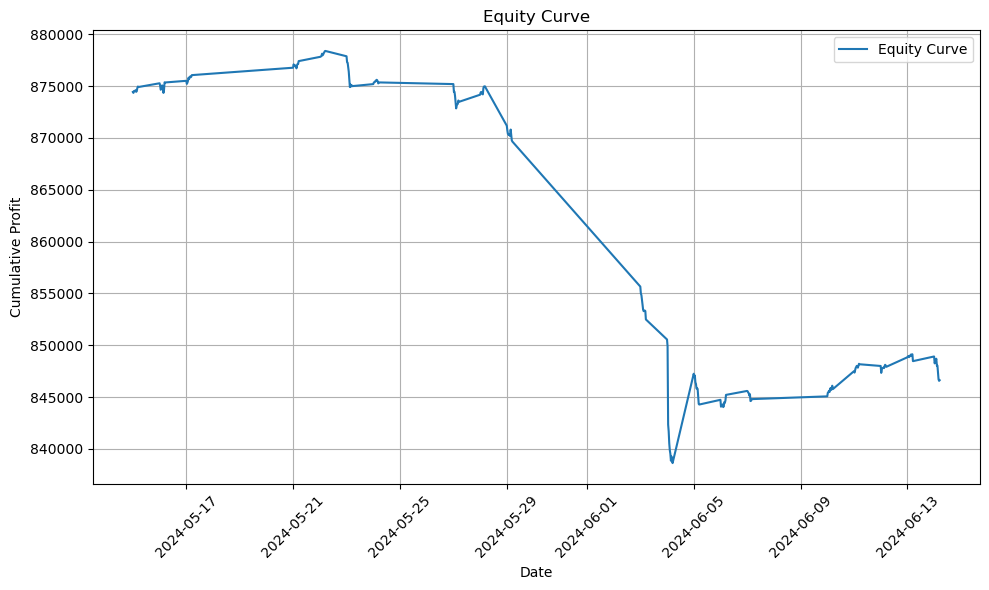

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# initial_balance = df['call_lot_size'][0] * df['CE'][0] + df['put_lot_size'][0] * df['PE'][0]

# Calculate period returns from total profit (since it's cumulative)
df['returns'] = df['Fund Balance'].pct_change()

# Use total_profit directly as the equity curve since it's already cumulative
df['equity_curve'] = df['Fund Balance']

# Calculate risk metrics
# 1. Period Return
period_return = (df['Fund Balance'].iloc[-1] - initial_balance) / initial_balance
num_periods = len(df)

# 2. Annualized Return - assuming the returns are for a longer period (e.g., monthly)
annualized_return = (1 + period_return) ** (252 / num_periods) - 1

# 3. Standard Deviation (Volatility) - using the period returns
annualized_volatility = df['returns'].std(ddof=1) * np.sqrt(252 / num_periods)

# 4. Sharpe Ratio
risk_free_rate = 0.04  # Adjust as needed
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

# 5. Maximum Drawdown
max_drawdown = (df['equity_curve'].cummax() - df['equity_curve']).max()

# Max Drawdown pct
max_drawdown_pct = ((df['Fund Balance'].cummax() - df['Fund Balance']).max() / initial_balance)

# 6. Sortino Ratio (using only downside deviation)
downside_returns = df['returns'].copy()
downside_returns[downside_returns > 0] = 0
downside_deviation = np.sqrt((downside_returns**2).mean()) * np.sqrt(252 / num_periods)
sortino_ratio = (annualized_return - risk_free_rate) / downside_deviation

# 7. Calmar Ratio
calmar_ratio = annualized_return / max_drawdown

# Print risk metrics
print(f"Period Return: {period_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility (Standard Deviation): {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2f}")
print(f"% Maximum Drawdown of Initial Fund Balance: {max_drawdown_pct:.2%}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")
print(f"Calmar Ratio: {calmar_ratio:.2f}")

# Plot the equity curve with dates
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['equity_curve'], label='Equity Curve')
plt.title('Equity Curve')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)  # Rotate date labels for better readability
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()